<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 34 · Probability</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Bayes' Theorem &amp; the Law of Total Probability 🔄</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:730px;line-height:1.6">Bayes' theorem reverses a conditional probability, turning P(evidence | cause) into P(cause | evidence). This notebook builds it from a tree, runs the Law of Total Probability that supplies its denominator, updates a prior into a posterior, accumulates evidence across two tests, and ends with a tiny naive Bayes classifier.</div>
  <div style="margin-top:16px;font-size:13px;color:#cbd5e1">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(34)
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
INDIGO="#4f46e5"; PINK="#db2777"; GREEN="#059669"
print("ready")

ready


<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 1 · BAYES FROM A TREE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Reverse the conditional</div>
<div style="color:#4a5578;margin-top:6px">Two machines make the same part. Machine A makes 60% of parts at a 2% defect rate; Machine B makes 40% at a 5% defect rate. A part is defective. Which machine most likely made it?</div>
</div>

In [2]:
# priors (which machine) and likelihoods (defect rate given machine)
pA, pB = 0.60, 0.40
p_def_A, p_def_B = 0.02, 0.05

# Law of Total Probability: the overall defect rate is a weighted average
p_def = pA*p_def_A + pB*p_def_B
print(f"P(defective) = 0.60*0.02 + 0.40*0.05 = {p_def:.3f}")

# Bayes: flip P(defect | machine) into P(machine | defect)
p_A_def = pA*p_def_A / p_def
p_B_def = pB*p_def_B / p_def
print(f"P(A | defective) = (0.60*0.02)/{p_def:.3f} = {p_A_def:.3f}")
print(f"P(B | defective) = (0.40*0.05)/{p_def:.3f} = {p_B_def:.3f}")
print(f"\nMost likely source of a defect: Machine {'B' if p_B_def>p_A_def else 'A'} ({max(p_A_def,p_B_def):.1%})")

P(defective) = 0.60*0.02 + 0.40*0.05 = 0.032
P(A | defective) = (0.60*0.02)/0.032 = 0.375
P(B | defective) = (0.40*0.05)/0.032 = 0.625

Most likely source of a defect: Machine B (62.5%)


Machine B makes fewer parts but is much more defect-prone, so among the defects it is the **more likely** source: P(B | defective) = 0.625. Notice the prior (40%) got *updated* by the evidence to 62.5%.

In [3]:
# verify by simulation
N=400_000
machine = rng.choice(["A","B"], size=N, p=[pA,pB])
defect  = rng.random(N) < np.where(machine=="A", p_def_A, p_def_B)
defects = machine[defect]
print(f"empirical P(B | defective) = {(defects=='B').mean():.3f}  (theory 0.625)")

empirical P(B | defective) = 0.622  (theory 0.625)


<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 2 · THE LAW OF TOTAL PROBABILITY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A weighted average over cases</div>
<div style="color:#4a5578;margin-top:6px">The denominator of Bayes is the Law of Total Probability: split the world into cases that cover everything, then average the conditional probabilities, weighted by how likely each case is.</div>
</div>

P(defective and from A) = 0.012
P(defective and from B) = 0.020
P(defective) = sum = 0.032


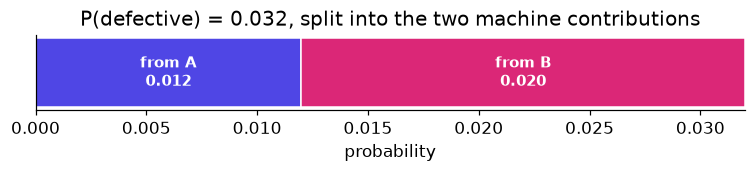

In [4]:
# P(defective) decomposed over the two machines
parts = {"from A": pA*p_def_A, "from B": pB*p_def_B}
total = sum(parts.values())
for k,v in parts.items():
    print(f"P(defective and {k}) = {v:.3f}")
print(f"P(defective) = sum = {total:.3f}")

fig,ax=plt.subplots(figsize=(7,1.7))
left=0
for (k,v),c in zip(parts.items(),[INDIGO,PINK]):
    ax.barh(0, v, left=left, color=c, edgecolor="white")
    ax.text(left+v/2, 0, f"{k}\n{v:.3f}", ha="center", va="center", color="white", fontweight="bold", fontsize=10)
    left+=v
ax.set_xlim(0,total); ax.set_yticks([]); ax.set_title("P(defective) = 0.032, split into the two machine contributions")
ax.set_xlabel("probability"); plt.tight_layout(); plt.show()

The Law of Total Probability says P(B) = &Sigma; P(B | A&#7522;) P(A&#7522;) over a partition {A&#7522;}. Here the two machines partition every part, so the total defect rate 0.032 is just the sum of the two slices. That total is exactly the number Bayes divides by.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 3 · PRIOR &rarr; POSTERIOR</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A medical test, the Bayesian way</div>
<div style="color:#4a5578;margin-top:6px">A disease has 0.5% prevalence. A test has 99% sensitivity and 95% specificity. The prevalence is the PRIOR; the test result is the EVIDENCE; Bayes gives the POSTERIOR.</div>
</div>

In [5]:
prior = 0.005                 # P(disease) before the test
sens  = 0.99                  # P(+ | disease)
spec  = 0.95                  # P(- | no disease)  ->  P(+ | no disease) = 0.05

p_pos = prior*sens + (1-prior)*(1-spec)        # Law of Total Probability
posterior = prior*sens / p_pos                 # Bayes
print(f"P(positive)            = {p_pos:.4f}")
print(f"prior     P(disease)   = {prior:.3f}")
print(f"posterior P(disease|+) = {posterior:.4f}  (about {posterior:.1%})")

P(positive)            = 0.0547
prior     P(disease)   = 0.005
posterior P(disease|+) = 0.0905  (about 9.0%)


A single positive test moves belief from 0.5% up to about **9%**. That is an 18-fold jump, yet it is still far from certain, because the disease is rare. Bayes keeps the base rate in the picture where intuition tends to drop it.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 4 · EVIDENCE ACCUMULATES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Yesterday's posterior is today's prior</div>
<div style="color:#4a5578;margin-top:6px">Bayesian updating is sequential: take a second, independent positive test. The posterior from the first test becomes the prior for the second.</div>
</div>

In [6]:
def update(prior, sens, spec):
    p_pos = prior*sens + (1-prior)*(1-spec)
    return prior*sens / p_pos

belief = 0.005
print(f"start (prior)      P(disease) = {belief:.4f}")
for k in range(1,5):
    belief = update(belief, sens, spec)
    print(f"after {k} positive test(s): P(disease) = {belief:.4f}  ({belief:.1%})")

start (prior)      P(disease) = 0.0050
after 1 positive test(s): P(disease) = 0.0905  (9.0%)
after 2 positive test(s): P(disease) = 0.6633  (66.3%)
after 3 positive test(s): P(disease) = 0.9750  (97.5%)
after 4 positive test(s): P(disease) = 0.9987  (99.9%)


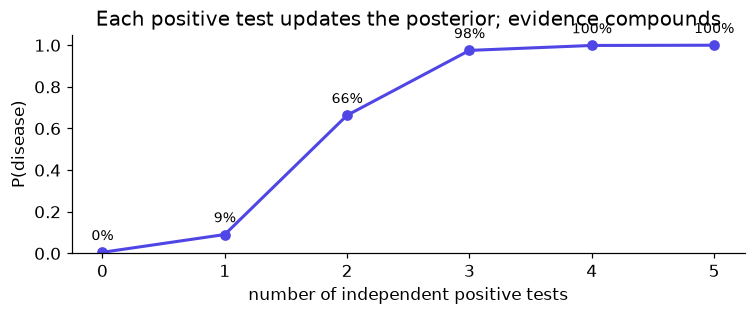

In [7]:
beliefs=[0.005]
for _ in range(5): beliefs.append(update(beliefs[-1], sens, spec))
fig,ax=plt.subplots(figsize=(7,3))
ax.plot(range(len(beliefs)), beliefs, "o-", color=INDIGO, lw=2)
ax.set_xlabel("number of independent positive tests"); ax.set_ylabel("P(disease)")
ax.set_title("Each positive test updates the posterior; evidence compounds")
for x,y in enumerate(beliefs): ax.annotate(f"{y:.0%}",(x,y),textcoords="offset points",xytext=(0,8),ha="center",fontsize=9)
ax.set_ylim(0,1.05); plt.tight_layout(); plt.show()

Two positive tests push P(disease) from 9% to about **66%**; a third crosses 97%. No single result is conclusive, but independent evidence compounds, which is the whole engine of Bayesian learning.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 5 · BAYES IN MACHINE LEARNING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A tiny naive Bayes spam filter</div>
<div style="color:#4a5578;margin-top:6px">A spam classifier is Bayes' theorem applied to words. Given the word 'free', is the email spam?</div>
</div>

In [8]:
p_spam = 0.40                 # prior: 40% of mail is spam
p_free_spam = 0.80            # P("free" | spam)
p_free_ham  = 0.10            # P("free" | not spam)

p_free = p_spam*p_free_spam + (1-p_spam)*p_free_ham      # total probability
p_spam_free = p_spam*p_free_spam / p_free                # Bayes
print(f"P(\"free\")            = {p_free:.3f}")
print(f"prior     P(spam)      = {p_spam:.2f}")
print(f"posterior P(spam|free) = {p_spam_free:.3f}  (about {p_spam_free:.0%})")

P("free")            = 0.380
prior     P(spam)      = 0.40
posterior P(spam|free) = 0.842  (about 84%)


The word "free" lifts the spam probability from a 0.40 prior to about **0.84**. A real naive Bayes filter multiplies many such word likelihoods together (the chain/multiplication rule from Chapter 31), each one nudging the posterior up or down. Bayes is the rule that turns features into a class probability.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ What you built</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You reversed a conditional with Bayes' theorem, computed its denominator with the Law of Total Probability, turned a prior into a posterior, accumulated evidence across repeated tests, and ran a one-word naive Bayes classifier. Every one of these is the same formula: posterior &prop; likelihood &times; prior.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>